In [1]:
import sys

sys.path.append('../src/')
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from libselection.utils import *
from libselection import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

## Data Generation

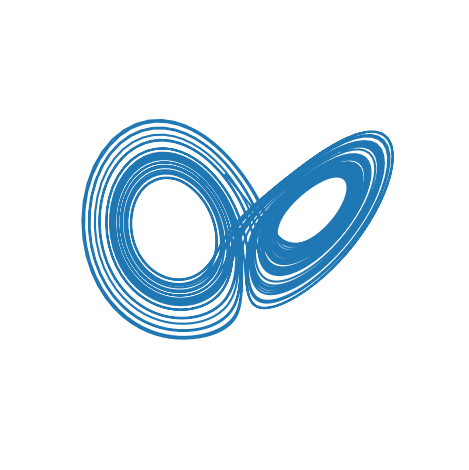

In [11]:
# Lorenz system parameters
sigma = 10.0
rho = 26.0
beta = 8.0 / 3.0

# Lorenz system equations
def lorenz_system(t, state):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

# Time range for simulation
dt = 0.01
t = np.arange(0, 50 + 2*dt, dt)
# Initial condition
initial_state = np.array([-8.0, 8.0, 27.0])

# Solve the Lorenz system
lorenz_data = solve_ivp(lorenz_system, (t[0], t[-1]), initial_state, method='RK45', t_eval=t, atol=1e-10).y.T

# # Normalize the data for simplicity
# lorenz_data = lorenz_data / np.max(np.abs(lorenz_data), axis=0)

# Plot the Lorenz attractor
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(lorenz_data[:, 0], lorenz_data[:, 1], lorenz_data[:, 2], lw=1.5)

ax.set_axis_off()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('Figs/lorenz_attractor.png', dpi=1200)



x_train = lorenz_data
t_train = t
var_names = ['x', 'y', 'z']

library_gen = ps.PolynomialLibrary(degree=3) #+ ps.FourierLibrary(n_frequencies=2)
D = np.array(library_gen.fit_transform(x_train))
_, No_D = D.shape
name_tag = np.array(library_gen.get_feature_names(var_names))
x_dot = non_uniform_diff(x_train, t_train)


## Compute Scores

### Standard formulation

(19, 20)


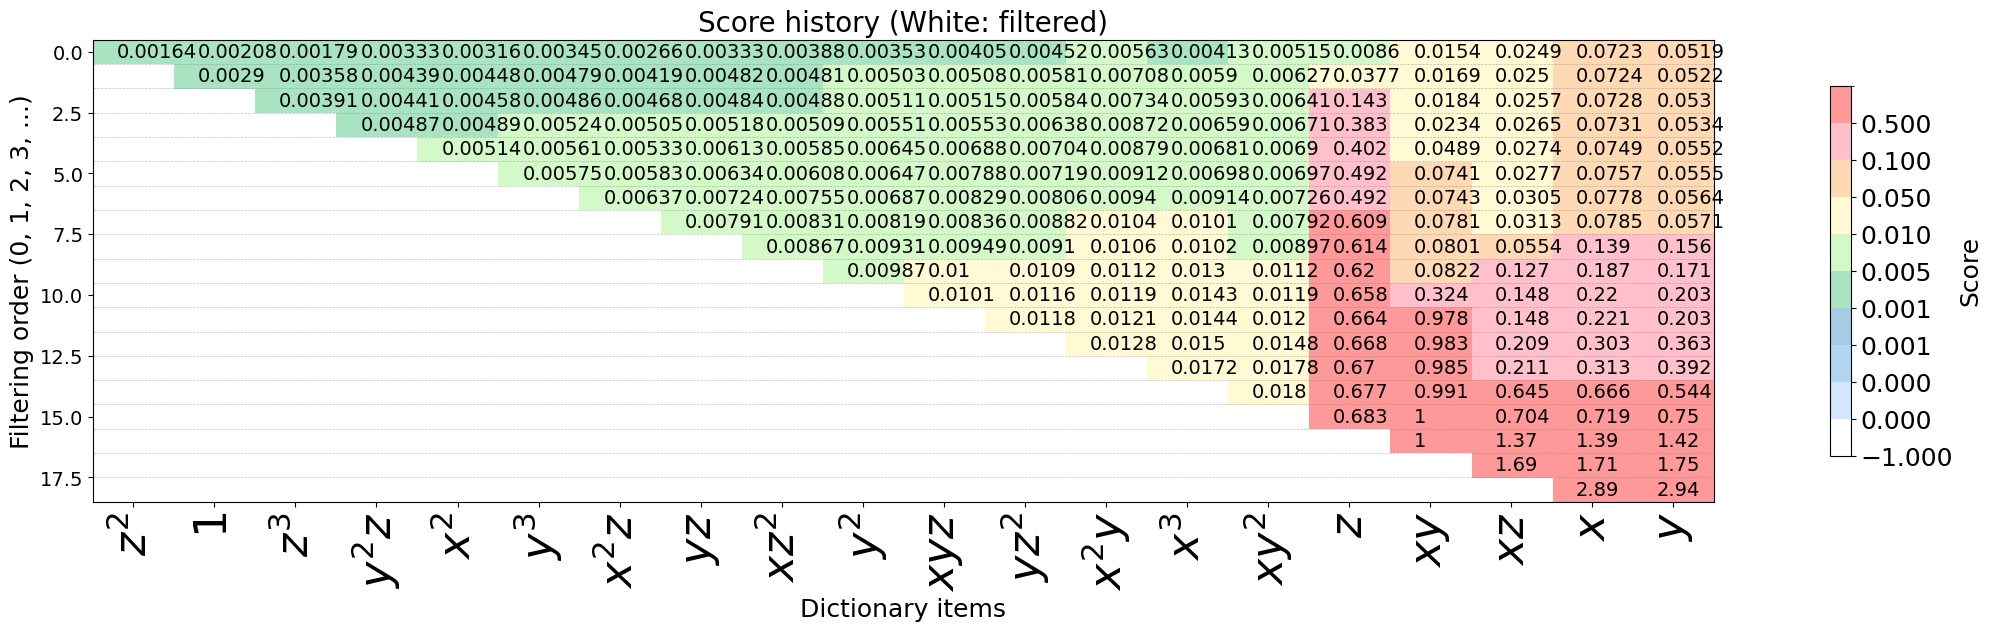

In [6]:
# Exhaustive filtering
plt.rcParams.update({'font.size': 14})
var = 1
best_comb, removed_order, history_values = iter_scores(D, x_dot, n_terms=1, stepwise=True, backwards=True, stepsize=1)

# plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path='Figs/filtering_history_lorenz.pdf', diff_score=False, backwards = True,print_inside=False,save_eps=True)
plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path=None, diff_score=False, backwards = True,print_inside=True,save_eps=True)

### Weak Form

(31, 32)


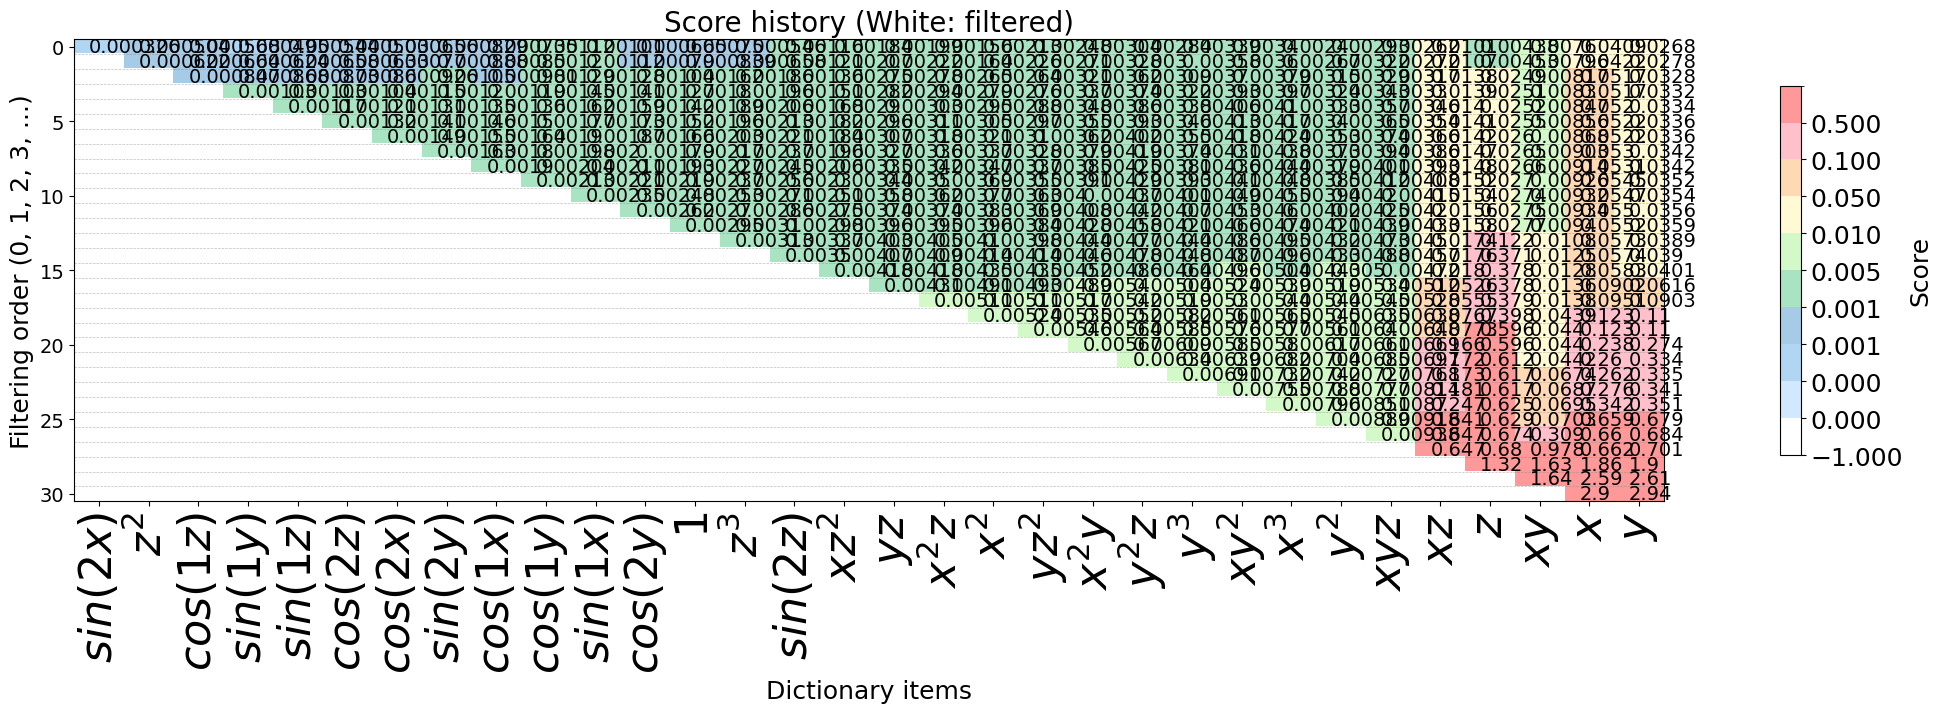

In [ ]:
# filtering
plt.rcParams.update({'font.size': 14})
V, dV = generate_overlapping_test_function_matrices(t_train, 2*No_D, l=0.25, p=16)
G = V@D
b = -dV@x_train
var = 1
best_comb, removed_order, history_values = iter_scores( G, b, n_terms=1, stepwise=True, backwards=True, stepsize=1)

# plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path=None, diff_score=False, backwards = True,print_inside=False)
# plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path='Figs/filtering_history_lorenz.pdf', diff_score=False, backwards = True,print_inside=False,save_eps=True)
plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path=None, diff_score=False, backwards = True,print_inside=True,save_eps=False)

### Component-wise scores (Weak form)

In [ ]:
history_value_removed = np.zeros((len(var_names),No_D))
filtering_order = np.zeros((len(var_names),No_D), dtype=int)

for var in range(len(var_names)):

    _, history_index, history_value = iter_scores( G, b[:,var:var+1], n_terms=1, stepwise=True, backwards=True, stepsize=1)
    # Determine the filtering order
    filtering_order[var,:] = history_index

    for i in range(No_D - 1):
        history_value_removed[var,i] = history_value[i, filtering_order[var,i]]
    history_value_removed[var,-1] = history_value[-1, filtering_order[var, -1]]

[29]
Jump in $x$ at index 31: y
Jump in $x$ at index 30: x
[28 29]
Jump in $y$ at index 31: x z
Jump in $y$ at index 30: x
Jump in $y$ at index 29: y
[29]
Jump in $z$ at index 31: x y
Jump in $z$ at index 30: z


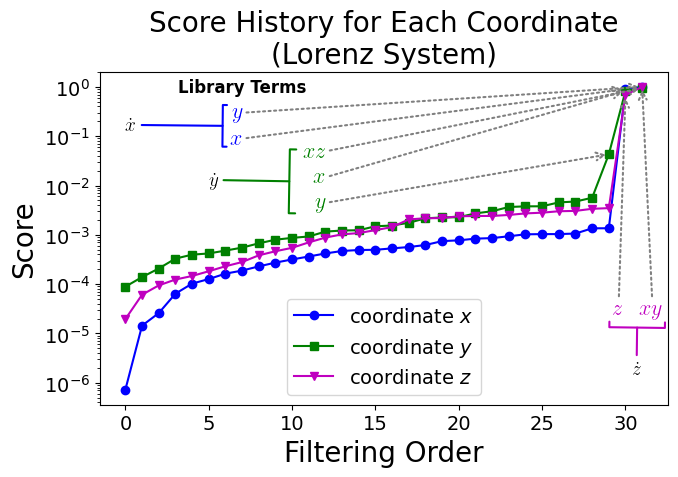

In [6]:
import matplotlib as mpl
plt.figure(figsize=(7, 5))
coords = ['$x$', '$y$', '$z$']
markers = ['o', 's', 'v']
colors = ['b', 'g', 'm']
for idx in range(3):
    plt.plot(history_value_removed[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
    

plt.xlabel('Filtering Order', fontsize=20)
plt.ylabel('Score', fontsize=20)
plt.title('Score History for Each Coordinate\n(Lorenz System)', fontsize=20)

# plt.xticks(np.arange(len(name_tag)), name_tag, rotation=90, fontsize=10)

# Detect and print jumps
height = 0.3
loc = 7
plt.text(
    loc, 1, 
    f"Library Terms", 
    ha='center', va='center', fontsize=12, color='k', fontweight='bold'
)
for idx in range(3):
    scores = history_value_removed[idx]
    jumps = np.where(((scores[1:]/scores[:-1]) > 5)*(scores[1:]> 0.008))[0] # Heuristic: jump > 10x median diff
    print(jumps)
    for j in range(No_D-2, jumps[0]-1,-1):
        print(f"Jump in {coords[idx]} at index {j+1}: {name_tag[filtering_order[idx, j+1]]}")
        # Set annotation color to match the line color
        line = plt.gca().lines[idx]
        color = line.get_color()
        # Draw an arrow to the jump point
        plt.annotate(
            '', 
            xy=(j+1, scores[j+1]), 
            xytext=(loc+0.1, height),  # Arrow starts from top left
            arrowprops=dict(arrowstyle="->", color='gray', lw=1.5,linestyle='dotted') ,
            annotation_clip=False
        )
        # Write the name at the top left, stacking vertically
        if idx < 2:
            with mpl.rc_context({'text.usetex': True, 'font.family': 'serif'}):
                plt.text(
                    loc, height, 
                    f"${name_tag[filtering_order[idx, j+1]]}$", 
                    ha='right', va='center', fontsize=16, color=color, fontweight='bold'
                )
            height *= 0.3  # Increment height for next annotation
        else:
            with mpl.rc_context({'text.usetex': True, 'font.family': 'serif'}):
                plt.text(
                    loc, height, 
                    f"${name_tag[filtering_order[idx, j+1]]}$", 
                    ha='center', va='top', fontsize=16, color=color, fontweight='bold'
                )

            loc -= 2  # Increment loc for next annotation
    with mpl.rc_context({'text.usetex': True, 'font.family': 'serif'}):
        if idx == 0:
            plt.annotate(
                '$\dot{x}$', 
                xy=(loc-1, height*6), 
                xytext=(loc-7, height*5.0),  # Arrow starts from top left
                arrowprops=dict(arrowstyle="-[", color=color, lw=1.5, mutation_scale=15) ,
                annotation_clip=False
            )
        elif idx == 1:
            plt.annotate(
                '$\dot{y}$', 
                xy=(loc-2, height*9), 
                xytext=(loc-7, height*7.65),  # Arrow starts from top left
                arrowprops=dict(arrowstyle="-[", color=color, lw=1.5,mutation_scale=23) ,
                annotation_clip=False
            )
        else:
            plt.annotate(
                '$\dot{z}$', 
                xy=(loc+3.2,  height*3e-1), 
                xytext=(loc+2.9, height*3e-2),  # Arrow starts from top left
                arrowprops=dict(arrowstyle="-[", color=color, lw=1.5, mutation_scale=20) ,
                annotation_clip=False,
            )
        if idx == 0:
            loc = 12
            height = 5e-2
        elif idx == 1:
            loc = 31.5
            height = 5e-5

plt.yscale('log')
# plt.legend(fontsize=14, loc='upper left', bbox_to_anchor=(1, 1))
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig('Figs/score_history_each_coordinate.pdf', format='pdf')
plt.show()

In [66]:
# Pareto & CV scores
history_value_pareto = np.zeros((3,No_D))
filtering_order_pareto = np.zeros((3,No_D), dtype=int)

history_value_cv = np.zeros((3,No_D))
filtering_order_cv = np.zeros((3,No_D), dtype=int)

for var in range(3):
    history_value_pareto[var,:], filtering_order_pareto[var,:] = get_pareto_scores(G, b[:,var:var+1])
    history_value_cv[var,:], filtering_order_cv[var,:] = get_cv_scores(G, b[:,var:var+1])


[]

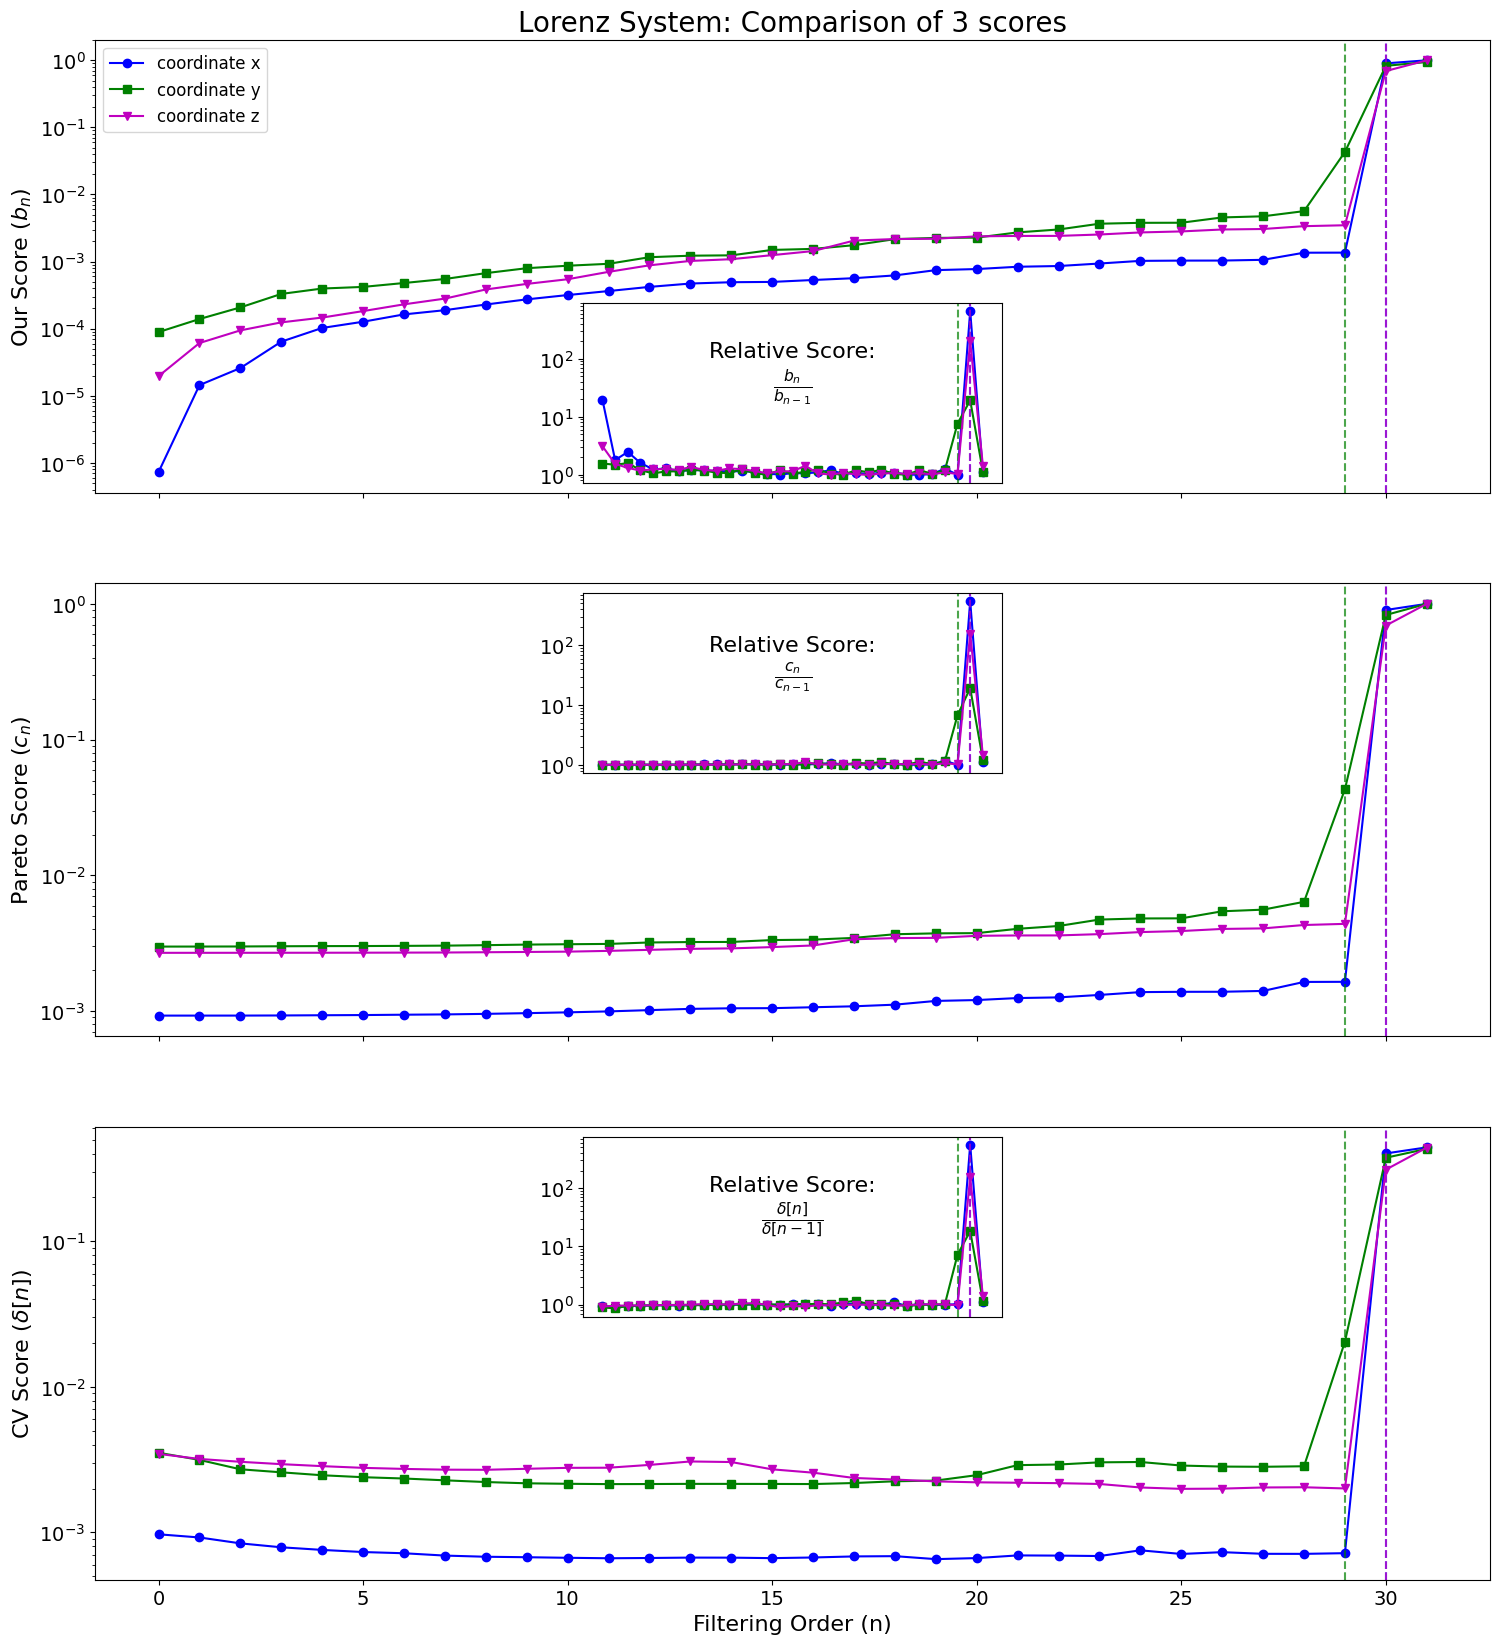

In [69]:
#create figure
fig, ax = plt.subplots(3,1,figsize=(18, 20), sharex=True)
ax[0].set_title('Lorenz System: Comparison of 3 scores', fontsize=20)
n_terms = [2, 3, 2]
n_terms = [No_D - n for n in n_terms]
# Our score
relative_score = history_value_removed[:,1:] / history_value_removed[:,:-1]
inset_ax = inset_axes(ax[0],
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='lower center')
for idx in range(history_value_removed.shape[0]):
    scores = history_value_removed[idx]
    ax[0].plot(history_value_removed[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
    ax[0].vlines(n_terms[idx], 0, 1, color=colors[idx], linestyle='dashed', alpha=0.7, transform=ax[0].get_xaxis_transform())



    # add an inset axis inside the top subplot
    inset_ax.plot(relative_score[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
    inset_ax.vlines(n_terms[idx]-1, 0, 1, color=colors[idx], linestyle='dashed', alpha=0.7, transform=inset_ax.get_xaxis_transform())





ax[0].set_yscale('log')
ax[0].set_ylabel('Our Score ($b_n$)', fontsize=16)
ax[0].legend(fontsize=12)

inset_ax.set_yscale('log')
inset_ax.annotate('Relative Score:\n$\\frac{b_n}{b_{n-1}}$', xy=(0.5, 0.5), xycoords='axes fraction', ha='center', fontsize=16)
inset_ax.set_xticks([])

# Pareto score
relative_score_pareto = history_value_pareto[:,1:] / history_value_pareto[:,:-1]
inset_ax_pareto = inset_axes(ax[1],
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='upper center')
for idx in range(history_value_pareto.shape[0]):
    ax[1].plot(history_value_pareto[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
    ax[1].vlines(n_terms[idx], 0, 1, color=colors[idx], linestyle='dashed', alpha=0.7, transform=ax[1].get_xaxis_transform())
    # add an inset axis inside the top subplot
    inset_ax_pareto.plot(relative_score_pareto[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
    inset_ax_pareto.vlines(n_terms[idx]-1, 0, 1, color=colors[idx], linestyle='dashed', alpha=0.7, transform=inset_ax_pareto.get_xaxis_transform())

ax[1].set_yscale('log')
ax[1].set_ylabel('Pareto Score ($c_n$)', fontsize=16)
inset_ax_pareto.set_yscale('log')
inset_ax_pareto.annotate('Relative Score:\n$\\frac{c_n}{c_{n-1}}$', xy=(0.5, 0.5), xycoords='axes fraction', ha='center', fontsize=16)
inset_ax_pareto.set_xticks([])

# CV score
relative_score_cv = history_value_cv[:,1:] / history_value_cv[:,:-1]
inset_ax_cv = inset_axes(ax[2],
                    width="30%", # width = 40% of parent_bbox
                    height=1.8, # height : 1 inch
                    loc='upper center')
for idx in range(history_value_cv.shape[0]):
    ax[2].plot(history_value_cv[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
    ax[2].vlines(n_terms[idx], 0, 1, color=colors[idx], linestyle='dashed', alpha=0.7, transform=ax[2].get_xaxis_transform())
    # add an inset axis inside the top subplot
    inset_ax_cv.plot(relative_score_cv[idx], color=colors[idx], marker=markers[idx], label=f'coordinate {coords[idx]}')
    inset_ax_cv.vlines(n_terms[idx]-1, 0, 1, color=colors[idx], linestyle='dashed', alpha=0.7, transform=inset_ax_cv.get_xaxis_transform())
ax[2].set_yscale('log')
ax[2].set_xlabel('Filtering Order (n)', fontsize=16)
ax[2].set_ylabel('CV Score ($\\delta[n]$)', fontsize=16)
inset_ax_cv.set_yscale('log')
inset_ax_cv.annotate('Relative Score:\n$\\frac{\\delta[n]}{\\delta[n-1]}$', xy=(0.5, 0.5), xycoords='axes fraction', ha='center', fontsize=16)
inset_ax_cv.set_xticks([])


C:\Users\fabio\AppData\Local\Temp\ipykernel_9820\1654681834.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


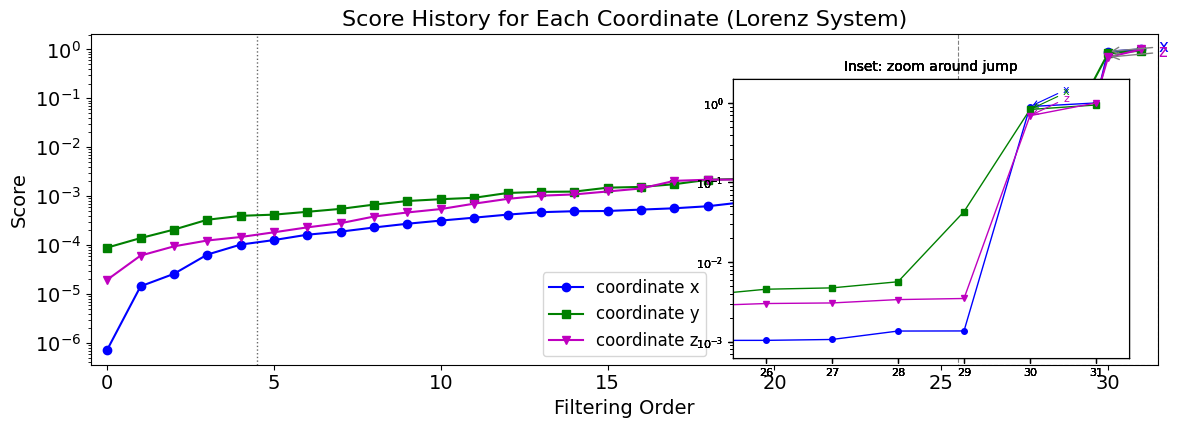

In [8]:
# Recreate the score-history plot for each coordinate (uses existing variables in the notebook)
No_D = history_value_removed.shape[1]
x = np.arange(No_D)

plt.figure(figsize=(12, 4.5))
coords = ['x', 'y', 'z']
colors = ['b', 'g', 'm']
markers = ['o', 's', 'v']

for idx in range(3):
    plt.plot(x, history_value_removed[idx], color=colors[idx], marker=markers[idx],
             linestyle='-', linewidth=1.5, markersize=6, label=f'coordinate {coords[idx]}')

plt.yscale('log')
plt.xlabel('Filtering Order', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.title('Score History for Each Coordinate (Lorenz System)', fontsize=16)
plt.legend(fontsize=12)
plt.xlim(-0.5, No_D-0.5)

# detect and annotate large jumps for each coordinate
for idx in range(3):
    scores = history_value_removed[idx]
    # avoid division by zero
    ratio = scores[1:] / (scores[:-1] + 1e-30)
    # heuristic: consider jumps where ratio is large and the jumped-to value is reasonably big
    jump_idxs = np.where((ratio > 50) & (scores[1:] > 1e-2))[0] + 1
    if jump_idxs.size == 0:
        # fallback: mark the single largest ratio if it's meaningful
        max_i = int(np.argmax(ratio)) + 1
        if ratio[max_i-1] > 20 and scores[max_i] > 1e-3:
            jump_idxs = np.array([max_i])
    for j in jump_idxs:
        term_idx = filtering_order[idx, j]  # index into name_tag
        term_name = name_tag[term_idx]
        y = scores[j]
        # draw simple arrow and text
        plt.annotate(
            f"{term_name}",
            xy=(j, y),
            xytext=(j + 1.5, max(y, 1e-3)), 
            arrowprops=dict(arrowstyle="->", color='gray', lw=1),
            fontsize=12, color=colors[idx]
        )

# optional vertical separators (align roughly with library groups in name_tag)
# adjust these indices if you want different group boundaries
sep = [4.5, 10.5, 19.5, 25.5, 27.5]
for s in sep:
    plt.axvline(s, color='k', linestyle=':', linewidth=1, alpha=0.6)

    # add an inset axis (zoom) inside the main figure
    ax = plt.gca()
    # figure coordinates [left, bottom, width, height]
    inset_ax = plt.axes([0.62, 0.18, 0.33, 0.62])

    # determine zoom window around detected jump (fallback to center)
    zoom_center = int(j) if 'j' in globals() else No_D // 2
    half_width = 4 
    x0 = max(0, zoom_center - half_width)
    x1 = min(No_D - 1, zoom_center + half_width)

    # plot same lines in the inset
    for ii in range(3):
        inset_ax.plot(x, history_value_removed[ii], color=colors[ii],
                      marker=markers[ii], linestyle='-', linewidth=1, markersize=4)

    # restrict view to the zoom window and keep log scale
    inset_ax.set_xlim(x0 - 0.5, x1 + 0.5)
    # compute y-limits from positive values in the zoom window (avoid -1 placeholders)
    sub = history_value_removed[:, x0:x1+1]
    pos = sub[sub > 0]
    if pos.size > 0:
        y_min, y_max = pos.min(), pos.max()
        inset_ax.set_ylim(y_min * 0.6, y_max * 2.0)
    inset_ax.set_yscale('log')

    # annotate the exact jump term inside the inset (if available)
    try:
        for ii in range(3):
            term_idx = int(filtering_order[ii, zoom_center])
            term_name = name_tag[term_idx]
            y = history_value_removed[ii, zoom_center]
            if y > 0:
                inset_ax.annotate(term_name, xy=(zoom_center, y),
                                  xytext=(zoom_center + 0.5, y * 1.5),
                                  arrowprops=dict(arrowstyle="->", color=colors[ii], lw=0.8),
                                  fontsize=8, color=colors[ii])
    except Exception:
        pass

    # styling
    inset_ax.tick_params(labelsize=8)
    inset_ax.set_title('Inset: zoom around jump', fontsize=10)
    # draw a rectangle on the main axis to indicate the zoom region
    rect_x0, rect_x1 = x0 - 0.5, x1 + 0.5
    rect = plt.Rectangle((rect_x0, plt.ylim()[0]), rect_x1 - rect_x0, plt.ylim()[1] - plt.ylim()[0],
                         edgecolor='gray', facecolor='none', linestyle='--', linewidth=0.8, transform=ax.get_xaxis_transform())
    # only add the rectangle in x (visual cue); skip if it would distort the main plot
    try:
        ax.add_patch(rect)
    except Exception:
        pass
plt.tight_layout()
# plt.savefig('Figs/score_history_each_coordinate_recreated.png', dpi=300)
plt.show()